# Laboratorio 01 - Pingüinos (Partes A-F)

Notebook enfocado exclusivamente en:
- Parte A: Observacion inicial
- Parte B: Descripcion
- Parte C: Visualizacion
- Parte D: Hipotesis (sin causalidad)
- Parte E: Pruebas estadisticas
- Parte F: Conclusiones y preguntas al investigador

In [2]:
import itertools
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_columns', 100)

df = sns.load_dataset('penguins')
display(df.head())
print(f'Dataset cargado con {df.shape[0]} filas y {df.shape[1]} columnas.')

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


Dataset cargado con 344 filas y 7 columnas.


## Parte A - Observacion inicial

In [8]:
# 1) Filas y columnas
n_filas, n_columnas = df.shape
print(f'1) Filas: {n_filas}, Columnas: {n_columnas}')

# 2) Variables numericas vs categoricas
num_cols = df.select_dtypes(include=np.number).columns.tolist()
cat_cols = [c for c in df.columns if c not in num_cols]
print('\n2) Variables numericas:')
print(num_cols)
print('Variables categoricas:')
print(cat_cols)

# 3) Valores faltantes por columna
faltantes = df.isna().sum().sort_values(ascending=False)
print('\n3) Valores faltantes por columna:')
display(faltantes.to_frame('faltantes'))

# 4) Filas duplicadas
duplicadas = df.duplicated().sum()
print(f'4) Filas duplicadas: {duplicadas}')

# 5) Variables de baja cardinalidad
umbral_baja_card = 10
baja_card = [c for c in cat_cols if df[c].nunique(dropna=True) <= umbral_baja_card]
print(f'5) Variables categoricas de baja cardinalidad (<= {umbral_baja_card} categorias):')
print(baja_card)

1) Filas: 344, Columnas: 7

2) Variables numericas:
['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
Variables categoricas:
['species', 'island', 'sex']

3) Valores faltantes por columna:


,faltantes
sex,11
bill_depth_mm,2
bill_length_mm,2
flipper_length_mm,2
body_mass_g,2
island,0
species,0


4) Filas duplicadas: 0
5) Variables categoricas de baja cardinalidad (<= 10 categorias):
['species', 'island', 'sex']


## Parte B - Descripcion

In [9]:
# 6) Estadisticos descriptivos para variables numericas
resumen_numerico = pd.DataFrame({
    'media': df[num_cols].mean(),
    'mediana': df[num_cols].median(),
    'desv_std': df[num_cols].std(),
    'Q1': df[num_cols].quantile(0.25),
    'Q3': df[num_cols].quantile(0.75)
})
resumen_numerico['IQR'] = resumen_numerico['Q3'] - resumen_numerico['Q1']
resumen_numerico = resumen_numerico[['media', 'mediana', 'desv_std', 'IQR']]
print('6) Resumen de variables numericas:')
display(resumen_numerico)

# 7) Conteos y porcentajes para variables categoricas
print('7) Conteos y porcentajes por variable categorica:')
cat_resumen = {}
for c in cat_cols:
    conteos = df[c].value_counts(dropna=False)
    porcentajes = df[c].value_counts(normalize=True, dropna=False) * 100
    tabla = pd.DataFrame({'conteo': conteos, 'porcentaje': porcentajes.round(2)})
    cat_resumen[c] = tabla
    print(f'\nVariable: {c}')
    display(tabla)

# 8) Tablas cruzadas para pares categoricos relevantes
print('8) Tablas cruzadas (conteos) para pares de variables categoricas:')
pares_categoricos = list(itertools.combinations(cat_cols, 2))
for c1, c2 in pares_categoricos:
    print(f'\nCrosstab: {c1} vs {c2}')
    ct = pd.crosstab(df[c1], df[c2], dropna=False)
    display(ct)

6) Resumen de variables numericas:


,media,mediana,desv_std,IQR
bill_length_mm,43.921930,44.45,5.459584,9.275
bill_depth_mm,17.151170,17.30,1.974793,3.100
flipper_length_mm,200.915205,197.00,14.061714,23.000
body_mass_g,4201.754386,4050.00,801.954536,1200.000


7) Conteos y porcentajes por variable categorica:

Variable: species


,conteo,porcentaje
species,,
Adelie,152,44.19
Gentoo,124,36.05
Chinstrap,68,19.77



Variable: island


...

island,Biscoe,Dream,Torgersen
species,,,
Adelie,44,56,52
Chinstrap,0,68,0
Gentoo,124,0,0



Crosstab: species vs sex


sex,Female,Male,NaN
species,,,
Adelie,73,73,6
Chinstrap,34,34,0
Gentoo,58,61,5



Crosstab: island vs sex


sex,Female,Male,NaN
island,,,
Biscoe,80,83,5
Dream,61,62,1
Torgersen,24,23,5


In [10]:
# 9) Correlaciones Pearson y Spearman
corr_pearson = df[num_cols].corr(method='pearson')
corr_spearman = df[num_cols].corr(method='spearman')

print('9) Matriz de correlacion (Pearson):')
display(corr_pearson)

print('Matriz de correlacion (Spearman):')
display(corr_spearman)

9) Matriz de correlacion (Pearson):


,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
bill_length_mm,1.000000,-0.235053,0.656181,0.595110
bill_depth_mm,-0.235053,1.000000,-0.583851,-0.471916
flipper_length_mm,0.656181,-0.583851,1.000000,0.871202
body_mass_g,0.595110,-0.471916,0.871202,1.000000


Matriz de correlacion (Spearman):


,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
bill_length_mm,1.000000,-0.221749,0.672772,0.583800
bill_depth_mm,-0.221749,1.000000,-0.523267,-0.432372
flipper_length_mm,0.672772,-0.523267,1.000000,0.839974
body_mass_g,0.583800,-0.432372,0.839974,1.000000


## Parte C - Visualizacion

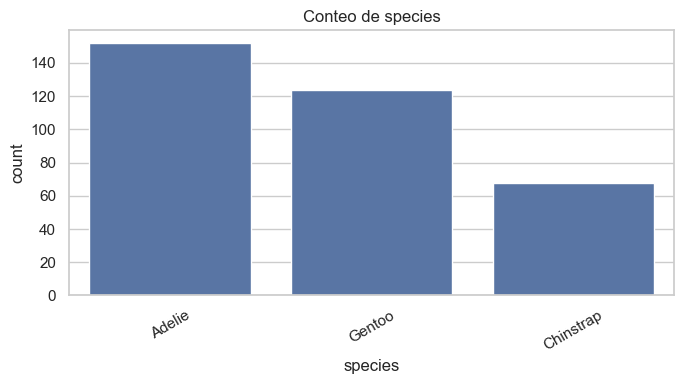

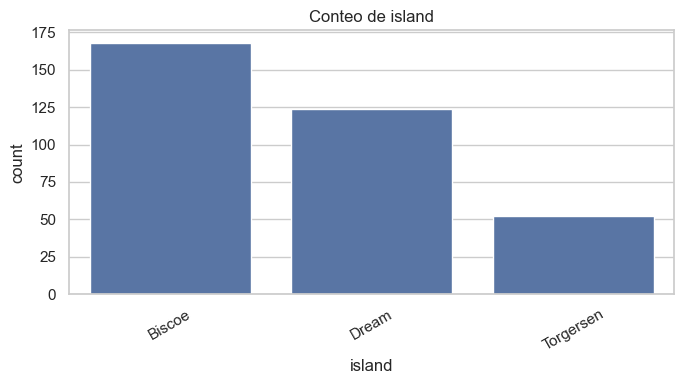

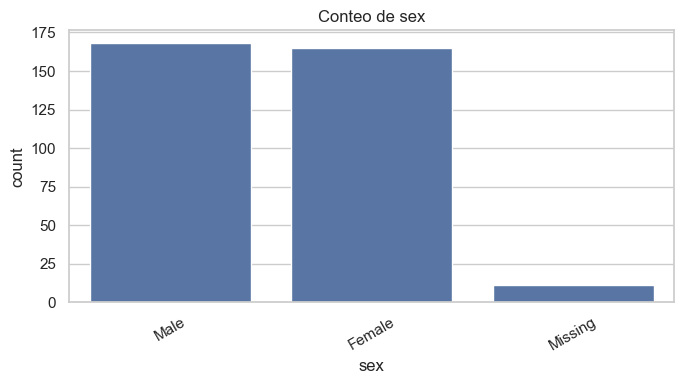

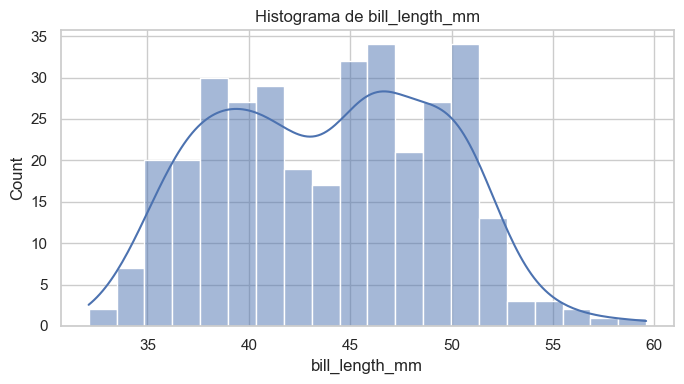

bill_length_mm: skew=0.053 -> aproximadamente simetrica


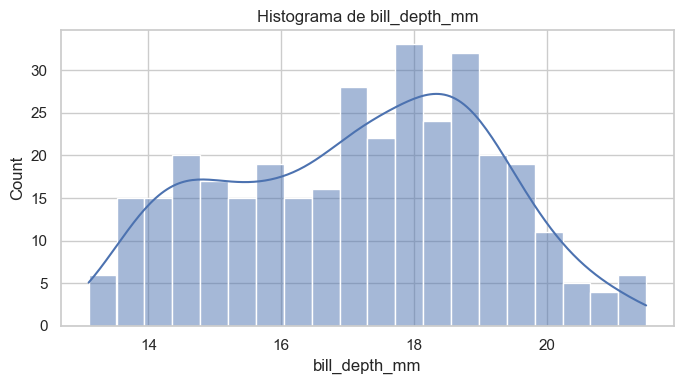

bill_depth_mm: skew=-0.143 -> aproximadamente simetrica


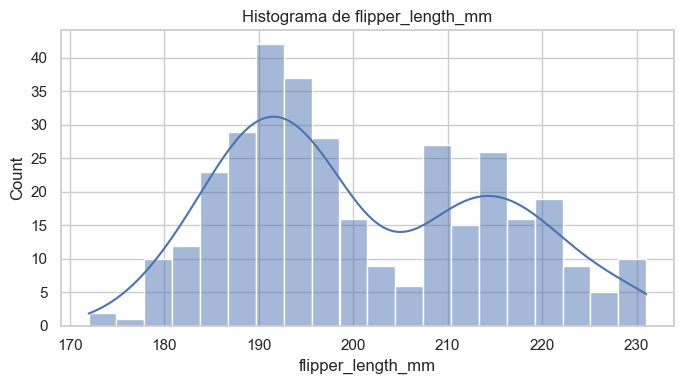

flipper_length_mm: skew=0.346 -> aproximadamente simetrica


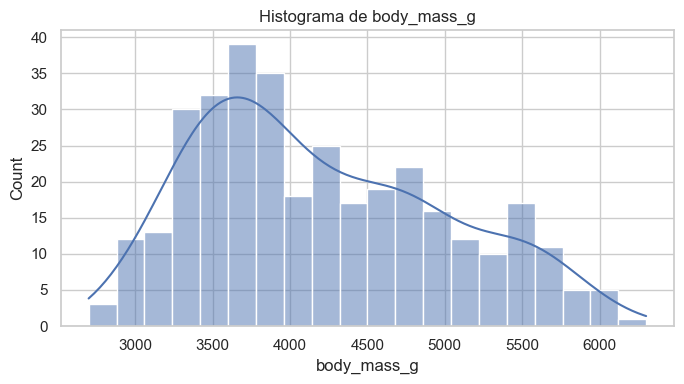

body_mass_g: skew=0.470 -> aproximadamente simetrica


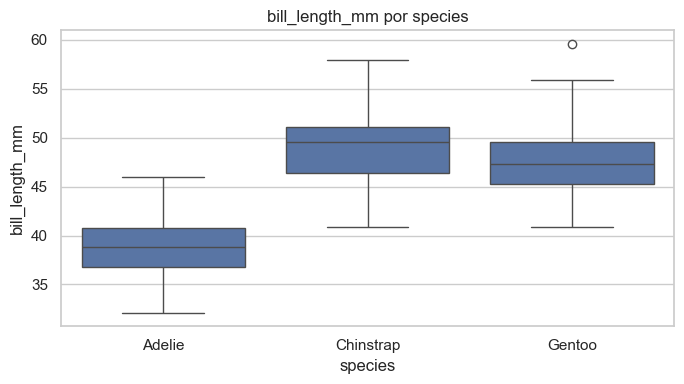

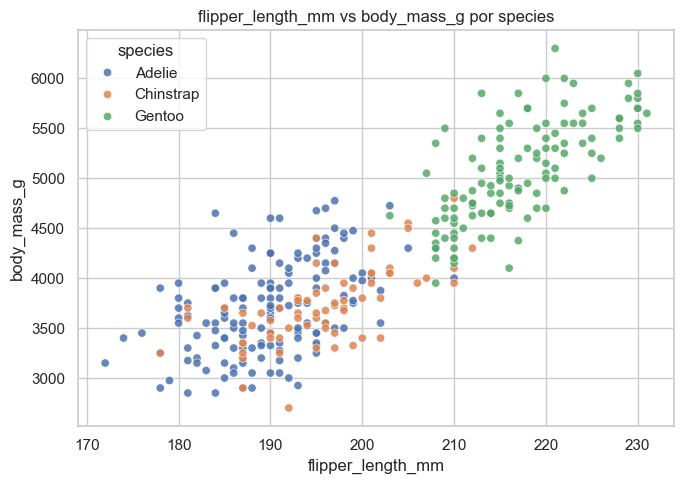

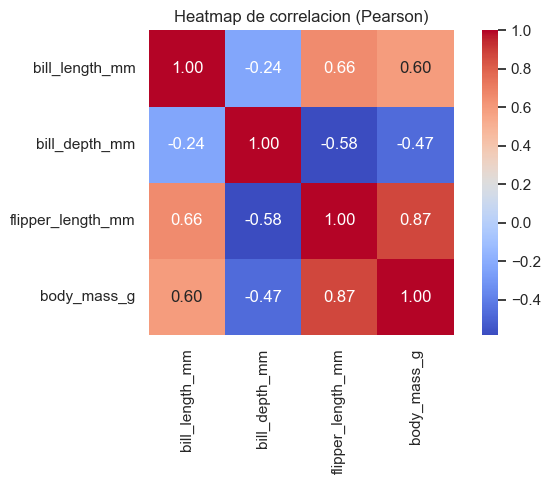

In [11]:
# 10) Graficos de conteo para categoricas de baja cardinalidad
for c in baja_card:
    serie_cat = df[c].astype('object').where(df[c].notna(), 'Missing')
    orden = serie_cat.value_counts().index
    plt.figure(figsize=(7, 4))
    sns.countplot(x=serie_cat, order=orden)
    plt.title(f'Conteo de {c}')
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

# 11) Histogramas y descripcion de forma
for c in num_cols:
    serie = df[c].dropna()
    plt.figure(figsize=(7, 4))
    sns.histplot(serie, kde=True, bins=20)
    plt.title(f'Histograma de {c}')
    plt.tight_layout()
    plt.show()

    skew = serie.skew()
    if skew > 0.5:
        forma = 'asimetria positiva (cola a la derecha)'
    elif skew < -0.5:
        forma = 'asimetria negativa (cola a la izquierda)'
    else:
        forma = 'aproximadamente simetrica'
    print(f'{c}: skew={skew:.3f} -> {forma}')

# 12) Boxplot: bill_length_mm por species
if 'bill_length_mm' in df.columns and 'species' in df.columns:
    plt.figure(figsize=(7, 4))
    sns.boxplot(data=df, x='species', y='bill_length_mm')
    plt.title('bill_length_mm por species')
    plt.tight_layout()
    plt.show()

# 13) Scatter: flipper_length_mm vs body_mass_g coloreado por species
if {'flipper_length_mm', 'body_mass_g', 'species'}.issubset(df.columns):
    plt.figure(figsize=(7, 5))
    sns.scatterplot(
        data=df,
        x='flipper_length_mm',
        y='body_mass_g',
        hue='species',
        alpha=0.85
    )
    plt.title('flipper_length_mm vs body_mass_g por species')
    plt.tight_layout()
    plt.show()

# 14) Heatmap de correlacion (Pearson)
plt.figure(figsize=(7, 5))
sns.heatmap(corr_pearson, annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title('Heatmap de correlacion (Pearson)')
plt.tight_layout()
plt.show()

## Parte D - Hipotesis (sin causalidad)

15) Hipotesis falsables propuestas:

- H1: `flipper_length_mm` se asocia monotonicamente con `body_mass_g`.
- H2: La distribucion de `bill_length_mm` difiere entre grupos de `species`.
- H3: `species` se asocia con `island`.

Estas hipotesis evaluan asociacion y diferencia de distribuciones, sin afirmar causalidad.

In [12]:
# Parte E - Pruebas estadisticas
alpha = 0.05
resultados = []

# H1: Spearman para flipper_length_mm vs body_mass_g
tmp = df[['flipper_length_mm', 'body_mass_g']].dropna()
rho, pval = stats.spearmanr(tmp['flipper_length_mm'], tmp['body_mass_g'])
resultados.append({
    'hipotesis': 'H1: flipper_length_mm asociado con body_mass_g',
    'prueba': 'Spearman',
    'estadistico': rho,
    'p_valor': pval,
    'decision_alpha_0.05': 'Apoya hipotesis' if pval < alpha else 'No hay evidencia suficiente'
})

# H2: Kruskal para bill_length_mm por species
tmp2 = df[['bill_length_mm', 'species']].dropna()
grupos = [g['bill_length_mm'].values for _, g in tmp2.groupby('species')]
H, pval2 = stats.kruskal(*grupos)
resultados.append({
    'hipotesis': 'H2: bill_length_mm difiere por species',
    'prueba': 'Kruskal-Wallis',
    'estadistico': H,
    'p_valor': pval2,
    'decision_alpha_0.05': 'Apoya hipotesis' if pval2 < alpha else 'No hay evidencia suficiente'
})

# H3: Chi-cuadrado para species vs island
tmp3 = df[['species', 'island']].dropna()
tabla = pd.crosstab(tmp3['species'], tmp3['island'])
chi2, pval3, dof, expected = stats.chi2_contingency(tabla)
resultados.append({
    'hipotesis': 'H3: species asociado con island',
    'prueba': 'Chi-cuadrado de independencia',
    'estadistico': chi2,
    'p_valor': pval3,
    'decision_alpha_0.05': 'Apoya hipotesis' if pval3 < alpha else 'No hay evidencia suficiente'
})

resultados_pruebas = pd.DataFrame(resultados)
display(resultados_pruebas)

,hipotesis,prueba,estadistico,p_valor,decision_alpha_0.05
0,H1: flipper_length_mm asociado con body_mass_g,Spearman,0.839974,2.763219e-92,Apoya hipotesis
1,H2: bill_length_mm difiere por species,Kruskal-Wallis,244.136718,9.691372e-54,Apoya hipotesis
2,H3: species asociado con island,Chi-cuadrado de independencia,299.550327,1.354574e-63,Apoya hipotesis


## Parte F - Conclusiones y reporte

19) Conclusiones en tres capas

A) Hallazgos descriptivos (con evidencia):
- El dataset contiene 344 filas y 7 columnas, con 0 filas duplicadas.
- Las variables numéricas presentan la siguiente tendencia central: `bill_length_mm` media=43.92, `bill_depth_mm` media=17.15, `flipper_length_mm` media=200.92 y `body_mass_g` media=4201.75.
- La dispersión es mayor en `body_mass_g` (IQR=1200) y `flipper_length_mm` (IQR=23), lo que sugiere alta variabilidad morfométrica entre individuos.
- Hay valores faltantes en `sex` (11 casos) y en variables morfométricas (2 casos por variable), por lo que el manejo de missing data es relevante para inferencia.

B) Patrones visuales (con evidencia):
- En los countplots, `Adelie` es la especie más frecuente; `Biscoe` es la isla más representada; en `sex` predominan levemente `Male` y `Female` con pocos `Missing`.
- El scatter de `flipper_length_mm` vs `body_mass_g` muestra una asociación positiva clara, coherente con la correlación de Pearson alta (`r=0.87`).
- El boxplot de `bill_length_mm` por `species` evidencia diferencias entre especies (por ejemplo, `Adelie` con valores más bajos que `Chinstrap`/`Gentoo`).
- El heatmap confirma relaciones moderadas/altas: positiva entre `bill_length_mm` y `flipper_length_mm` (`r=0.66`) y negativa entre `bill_depth_mm` y `flipper_length_mm` (`r=-0.58`).

C) Próximas hipótesis a probar:
- Evaluar si la relación entre `flipper_length_mm` y `body_mass_g` cambia al estratificar por `species` (interacción).
- Probar si las diferencias en `bill_depth_mm` entre especies se mantienen controlando por isla.
- Analizar si la variable `sex` modifica asociaciones morfométricas dentro de cada especie.

20) Preguntas para un investigador 
- ¿Cuál es la estrategia más adecuada para tratar los faltantes de `sex` (imputación, categoría explícita o exclusión) según el objetivo analítico?
- ¿Se debe controlar sistemáticamente por `species` e `island` para evitar confusión en pruebas de asociación?
- ¿Qué variables externas (edad, temporada, dieta o sitio de muestreo detallado) podrían explicar la variabilidad restante?

Resumen de la Parte E (sin causalidad):
- H1 (`flipper_length_mm` vs `body_mass_g`): Spearman = 0.840, p < 0.001 -> evidencia a favor de asociación.
- H2 (`bill_length_mm` por `species`): Kruskal-Wallis = 244.14, p < 0.001 -> evidencia de diferencias entre especies.
- H3 (`species` vs `island`): Chi-cuadrado = 299.55, p < 0.001 -> evidencia de asociación entre variables categóricas.

Estas conclusiones describen asociaciones y diferencias observadas; no implican causalidad.